In [2]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
from datasets.dataset import SimulationXZDataset
import time 
import time 
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id
import numpy as np
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
# from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, predict_modified_diffusion

In [3]:
results_folders = ['/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_05_11_08_13/rescaling/n_steps_3',
    '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_04_14_33_46/rescaling/n_steps_3',
'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_04_14_28_07/rescaling/n_steps_1'
]

0.02978916745632887
0.0351499809573094
0.032080470894773803


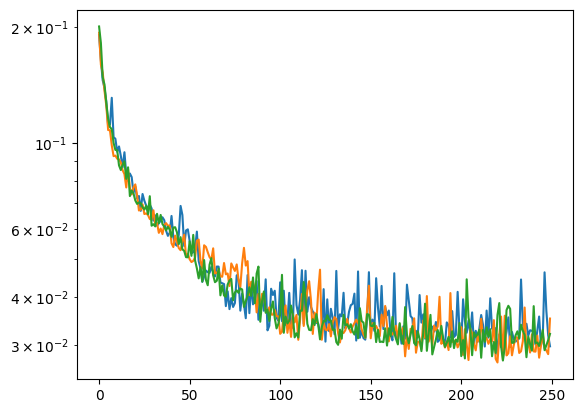

In [4]:
# results_folders[0]
for result in results_folders:
    loss = np.loadtxt(os.path.join(result, 'test_loss.txt'))
    train_loss = np.loadtxt(os.path.join(result, 'train_loss.txt'))
    print(loss[-1])
    plt.plot(loss)
    # plt.plot(train_loss)
    plt.yscale('log')
    # plt.show()

In [5]:
encoder_results_dir = results_folders[-1]#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_14_20_37_48/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_14_20_37_48/standardize/n_steps_1'
timesteps = 1000
conditioning = 'implicit'
encoding = 'True'
schedule = 'linear'
device= 'cuda'
encode_bool = encoding == 'True'

os.environ['CUDA_VISIBLE_DEVICES']  = "6"
batch_size = 1
downscale_method = 'direct'
analysis_folder = f'analyzed_figures_paper_3_5/{timesteps}_{conditioning}_{schedule}_{downscale_method}'
os.makedirs( analysis_folder, exist_ok = True)

data_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_v3_laser_velocity_xz_cross_section_data'#'/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data'#'/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data'
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = data_folder , return_info = True, n_steps = 1, normalize = 'rescaling', out_steps = 1)
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = data_folder, return_info = True, n_steps = 1, normalize = 'rescaling', out_steps = 1)
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = data_folder, return_info = True, n_steps = 1, normalize = 'rescaling', out_steps = 1)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... rescaling
Using all 1 fields
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using all 1 fields
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using all 1 fields
Processing dataset with 1 fields


In [6]:
from models.lr_encoder_model import rrdbnet_encoder
def load_encoder(encoder_results_dir, dataset):
    device = 'cuda'
    lr_enc  = rrdbnet_encoder(upscale_factor = dataset.factor, in_channels = dataset.n_steps*dataset.num_fields, out_channels = dataset.out_steps)
    # lr_enc = rrdbnet_x4(upscale_factor = 4, num_blocks = 8)

    lr_enc.to(device)
    lr_encoptimizer = torch.optim.Adam(lr_enc.parameters())
    lrenc_fname = os.path.join(encoder_results_dir, 'model_saved.pth')
    lrenc_checkpoint = torch.load(lrenc_fname)
    lr_enc.load_state_dict(lrenc_checkpoint['model_state_dict'])
    lr_encoptimizer.load_state_dict(lrenc_checkpoint['optimizer_state_dict'])
    lr_enc.eval()
    return lr_enc

In [7]:
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)

In [26]:
last_power = ''
modeltype = 'Diffusion' # Defines part of the title of the image
enc_depths_sim = []
diff_depths_sim = []
gt_depths_sim = []

enc_kp_sim = []
diff_kp_sim = []
gt_kp_sim = []
gt_results = {}
enc_results = {}
diff_results = {}
skip = 50
targets = []
results = []
inputs = []
upscaled_lrs = []
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(train_dataloader), total = len(train_dataloader)):  
   

    oldtime = time.time()

    input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    inputs.append(input)
    results.append(result)
    targets.append(target)
    upscaled_lrs.append(train_dataloader.dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr'))
    info = info[0] # info is technically returned with an extra dimension, this command removes it.
    time_elapsed = time.time()-oldtime
    # print(last_power)
    if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
        
        timestep = 0

        enc_depths_sim = []
        diff_depths_sim = []
        gt_depths_sim = []

        enc_kp_sim = []
        diff_kp_sim = []
        gt_kp_sim = []

    else:
        timestep += 1
    profile_gt, kp_gt = get_profile(target[0])
    profile_enc, kp_enc = get_profile(result[0])


    enc_kp_sim.append(5*(80-np.min(kp_enc)))
    gt_kp_sim.append(5*(80-np.min(kp_gt)))


    enc_depths_sim.append(5*(80-np.min(profile_enc)))
    gt_depths_sim.append(5*(80-np.min(profile_gt)))

    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_kp_sim
    enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_kp_sim
    gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_depths_sim
    enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_depths_sim
    # if batch_idx > 3:
    #     break

100%|██████████| 2970/2970 [00:57<00:00, 51.94it/s]


In [39]:
# results[i][0,0].shape#[10,40-c]
targets[i].shape

torch.Size([1, 1, 80, 80])

tensor(2096.9194)


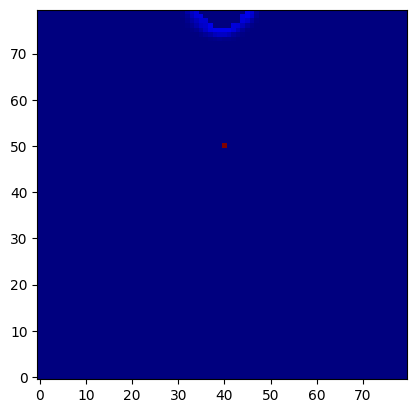

tensor(1991.7307)


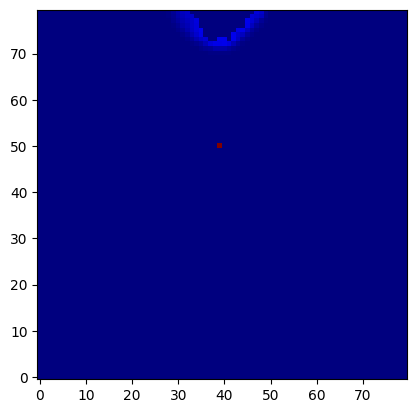

tensor(1879.3997)


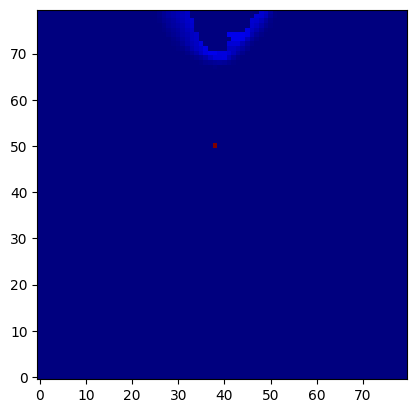

tensor(1789.7898)


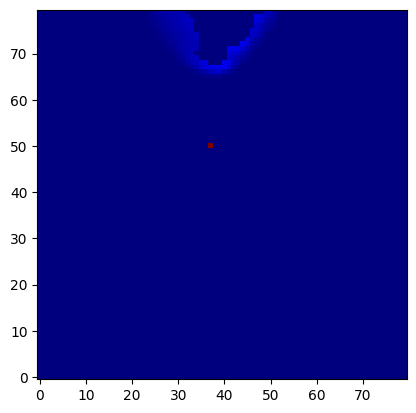

tensor(1690.7841)


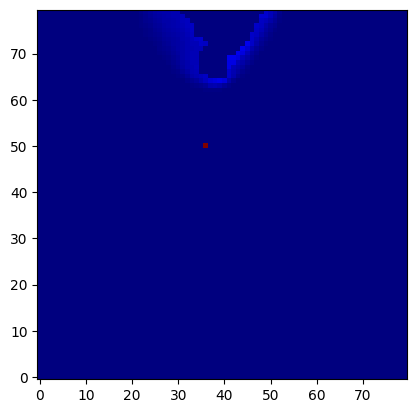

tensor(1560.6003)


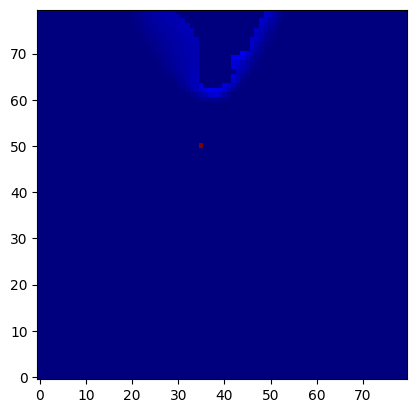

tensor(1433.2671)


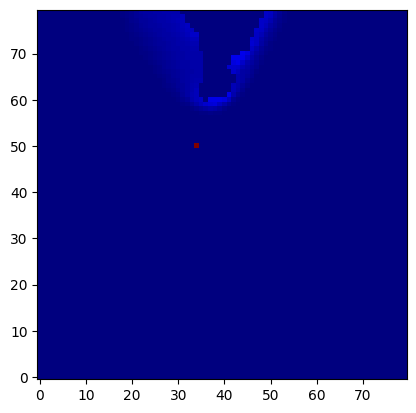

tensor(1276.4211)


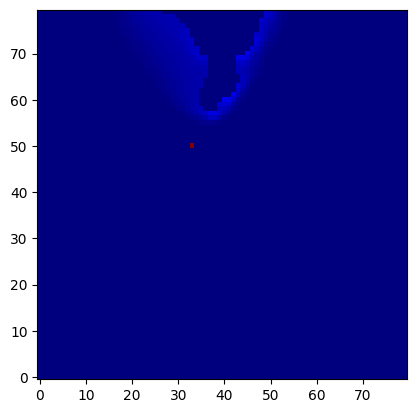

tensor(1149.2617)


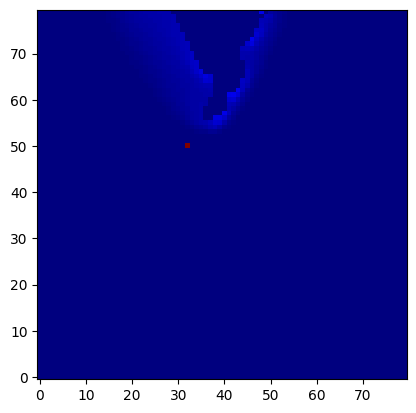

tensor(1003.7057)


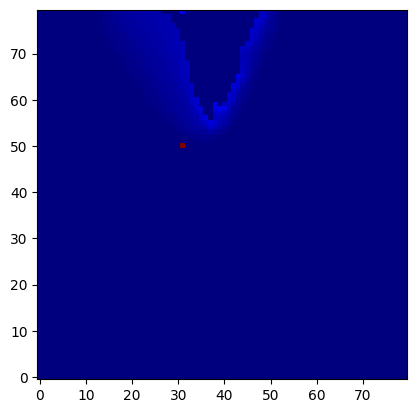

tensor(872.7826)


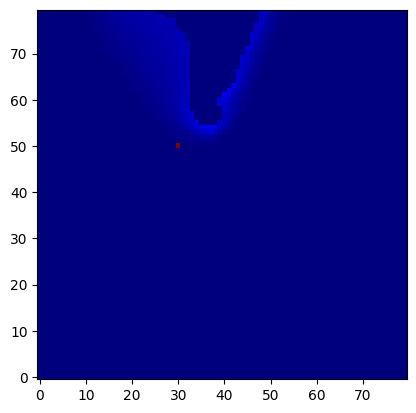

tensor(732.8946)


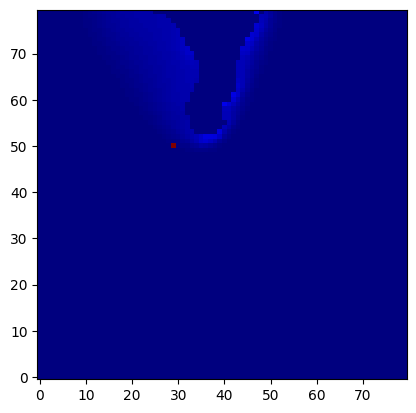

tensor(634.8997)


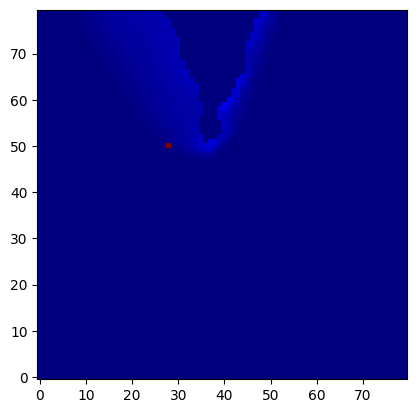

tensor(545.6587)


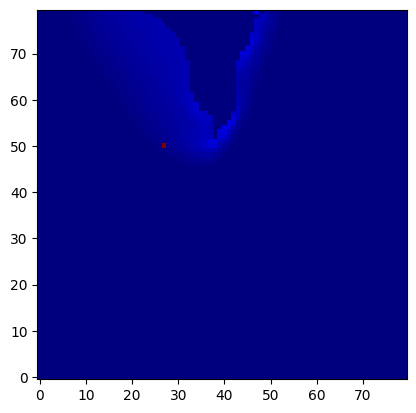

tensor(475.3439)


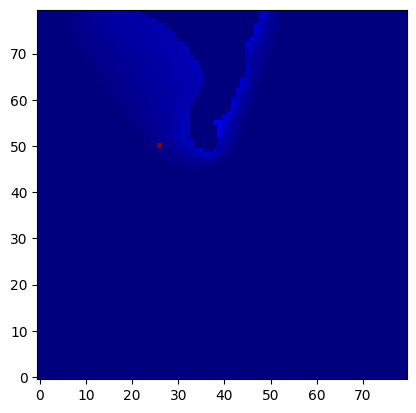

tensor(412.0597)


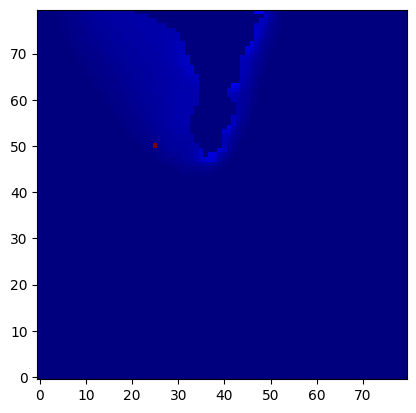

tensor(372.1718)


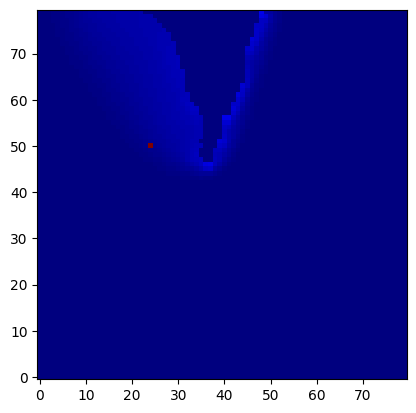

tensor(342.2868)


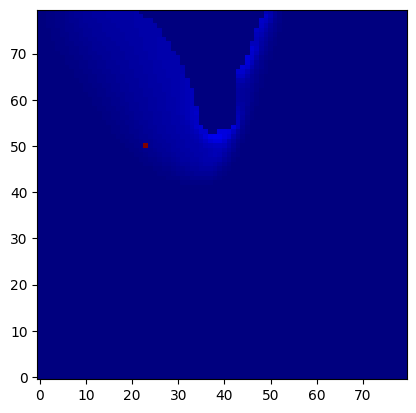

tensor(326.0525)


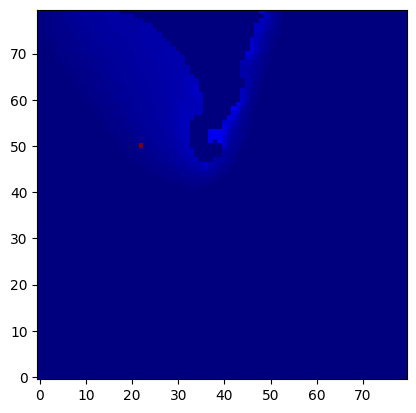

tensor(315.8308)


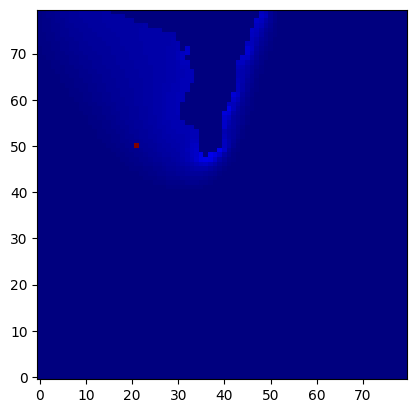

tensor(308.1658)


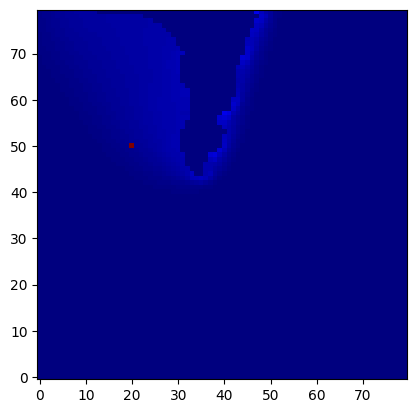

tensor(302.3271)


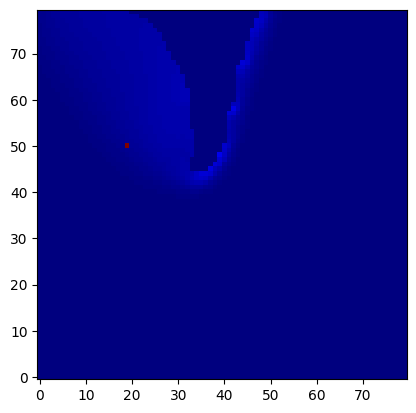

tensor(299.8961)


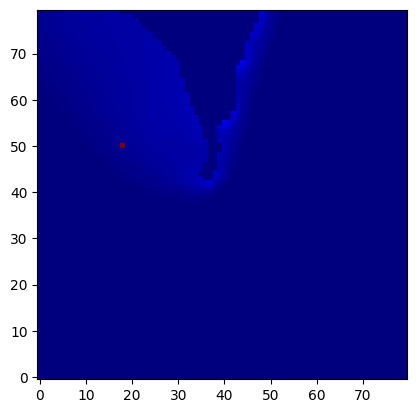

tensor(297.4372)


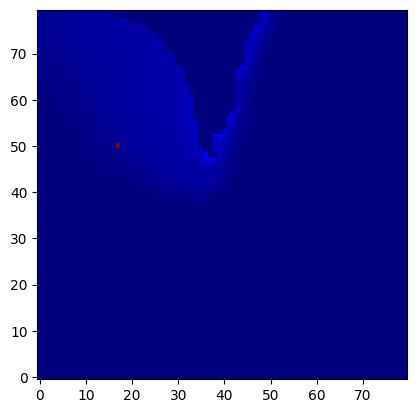

tensor(291.8985)


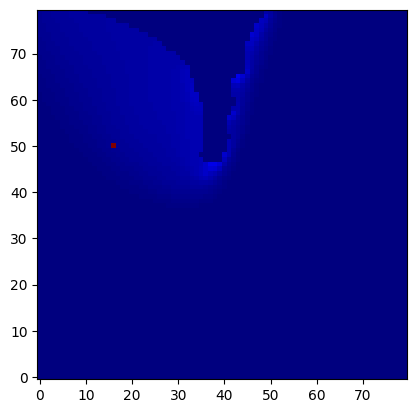

tensor(287.1784)


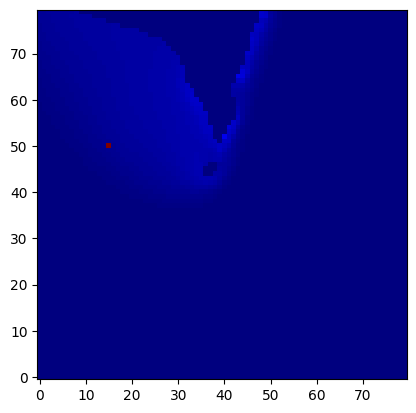

tensor(287.5106)


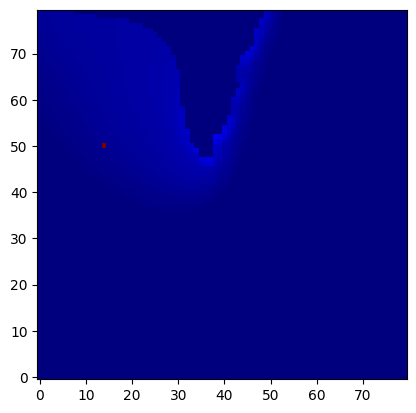

tensor(286.4377)


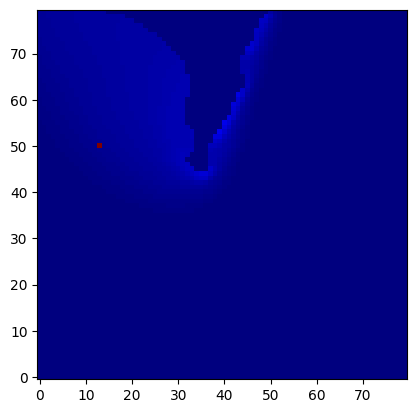

tensor(282.0408)


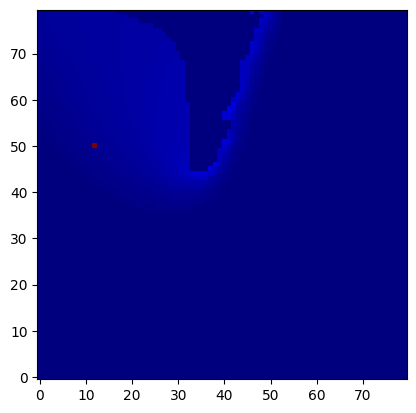

tensor(279.7941)


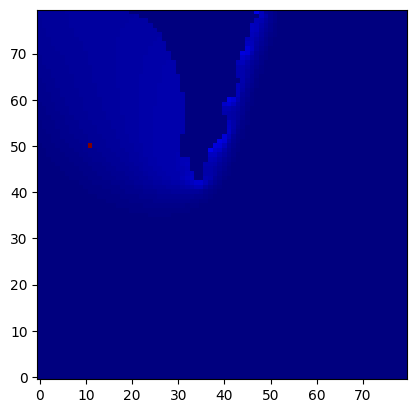

tensor(281.2274)


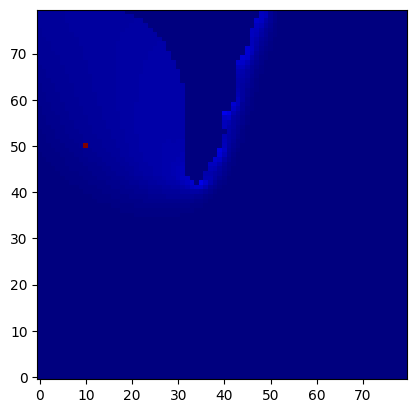

tensor(283.6156)


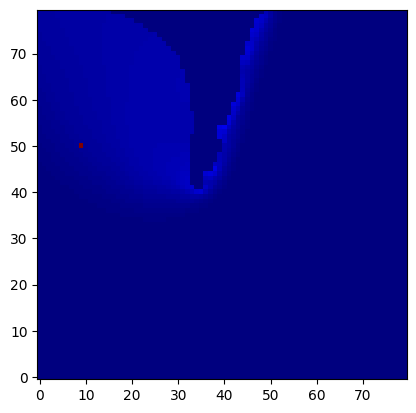

tensor(285.2493)


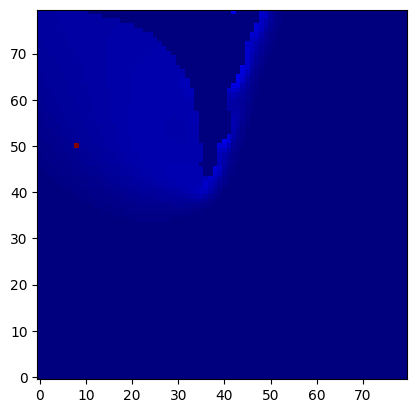

tensor(283.6406)


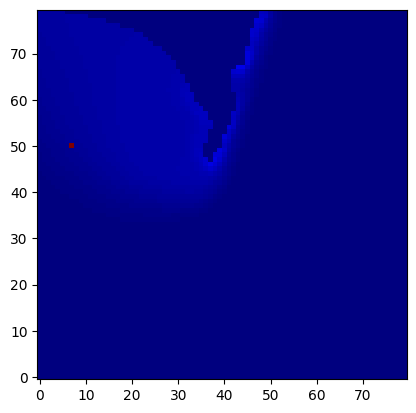

tensor(279.6409)


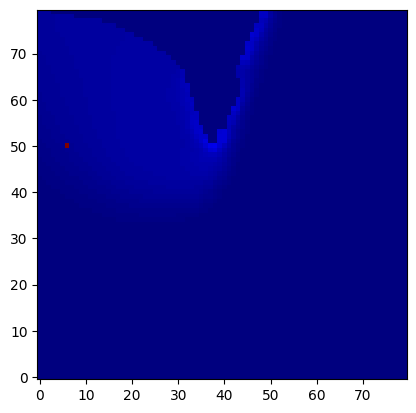

tensor(274.6820)


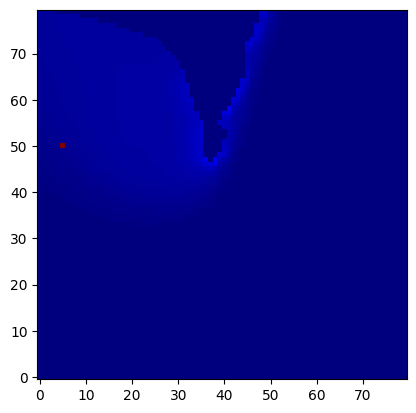

tensor(275.4291)


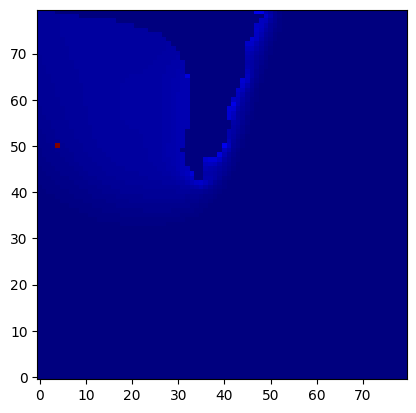

tensor(275.9541)


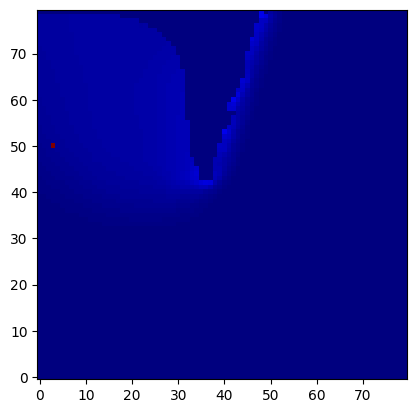

tensor(278.9819)


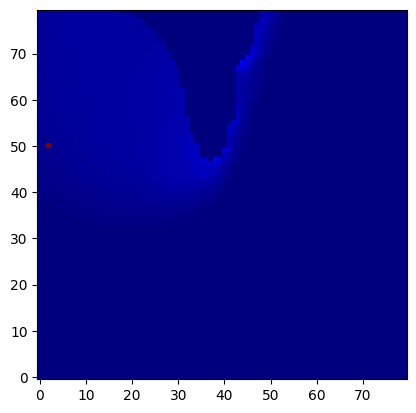

tensor(285.5859)


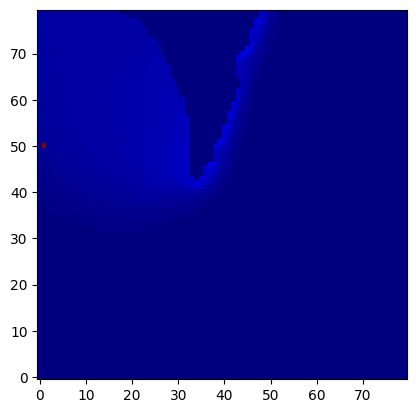

tensor(293.2358)


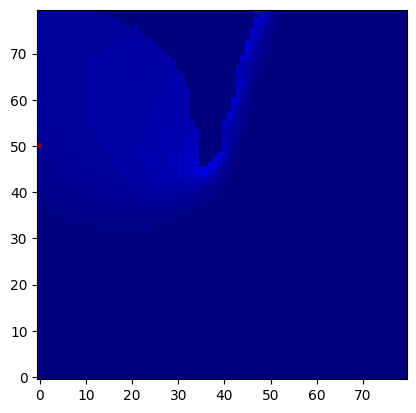

tensor(333.4440)


In [52]:
# results[-1]
1.1*5e-6
resultTs = []
inputTs = []
targetTs=[]
c = 0
for i in range(len(results)-98, len(results)):
    print(result[-1][0][10,40-c])
    if c > 40:
        break
    # if c % 4 == 0: 
        # inputTs.append(input[-1])
    else:
        resultTs.append(results[i][0,0][40-c,50])
        targetTs.append(targets[i][0,0][40-c,50])
        inputTs.append(upscaled_lrs[i][0,0][40-c,50])
        sample = np.copy(targets[i][0,0].cpu().numpy())
        sample[40-c,50] = 10*np.max(sample)
        plt.imshow(sample.T, origin = 'lower', cmap = 'jet')
        plt.show()
        
        # plt.show()


    c += 1

(10.0, 40.0)

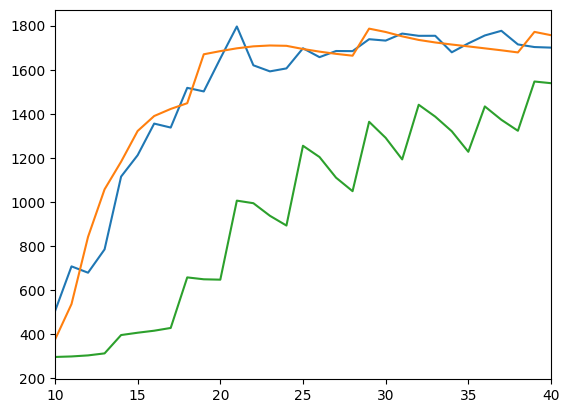

In [53]:
plt.plot(resultTs)
plt.plot(targetTs)
plt.plot(inputTs)
plt.xlim([10, 40])

In [8]:
max_depth_gt = []
max_depth_input = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
sample_times = []
steps_list= []
skip  = 50
mesh_hr = 5
factor =4 
mesh_lr = 20
kp_depth_diff = []
max_depth_diff = []
max_depth_input= []
kp_depth_input = []
max_depth_gt  = []
kp_depth_gt = []
l1loss = []
l1_fn = torch.nn.L1Loss()
encode_bool = True 
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(test_dataloader), total = len(test_dataloader)):  
    oldtime = time.time()
    # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset, skip = skip)
    input, result, target = predict_lrenc(lr_enc, res, hr, lr, upscaled_lr,dataset =  test_dataset)

    for i, rd in enumerate(result):
        elapsed = time.time() - oldtime
        l1loss.append(l1_fn(lr_enc(lr.float().to(device)), hr.float().to(device)).item())
        profile_diff, kp_diff = get_profile(result[i])
        profile_gt, kp_gt = get_profile(target[i])
        profile_input, kp_input = get_profile(input[i], mesh = 20)
      
        max_depth_gt.append(mesh_hr*(20*factor - np.min(profile_gt)))
        max_depth_diff.append(mesh_hr*(20*factor  -np.min(profile_diff)))
        max_depth_input.append(mesh_lr*(20 - np.min(profile_input)))
        kp_depth_gt.append(mesh_hr*(20*factor-np.min(kp_gt)))
        kp_depth_input.append(mesh_lr*(20-np.min(kp_input)))
        kp_depth_diff.append(mesh_hr*(20*factor-np.min(kp_diff)))
      
 
kp_depth_diffs.append(kp_depth_diff)
max_depth_diffs.append(max_depth_diff)

print(kp_depth_diffs)

100%|██████████| 693/693 [00:23<00:00, 28.98it/s]

[[0, 5, 5, 10, 10, 10, 5, 10, 5, 5, 10, 10, 10, 10, 15, 15, 20, 20, 20, 25, 25, 30, 40, 40, 40, 35, 35, 35, 40, 35, 35, 35, 40, 40, 40, 40, 40, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 50, 50, 50, 50, 50, 50, 50, 50, 45, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 10, 5, 10, 10, 10, 15, 20, 15, 20, 45, 65, 75, 75, 70, 60, 60, 45, 50, 70, 75, 65, 55, 55, 65, 85, 80, 70, 75, 80, 80, 75, 75, 80, 80, 85, 80, 75, 75, 75, 75, 75, 75, 75, 80, 80, 75, 75, 70, 75, 75, 75, 70, 70, 75, 70, 70, 70, 70, 75, 75, 75, 75, 75, 75, 80, 80, 75, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 85, 85, 85, 85, 85, 85, 10, 5, 10, 15, 25, 25, 40, 40, 40, 40, 40, 50, 55, 55, 60, 60, 65, 65, 60, 60, 65, 65, 70, 70, 70, 70, 70, 75, 70, 70, 75, 80, 80, 80, 80, 85, 80, 80, 80, 85, 85, 85, 85, 85, 85, 85, 85, 85, 90, 90, 90, 90, 90, 90

In [59]:
# plt.hist(l1loss, bins = 200)
np.mean(l1loss)

0.03243289156958009

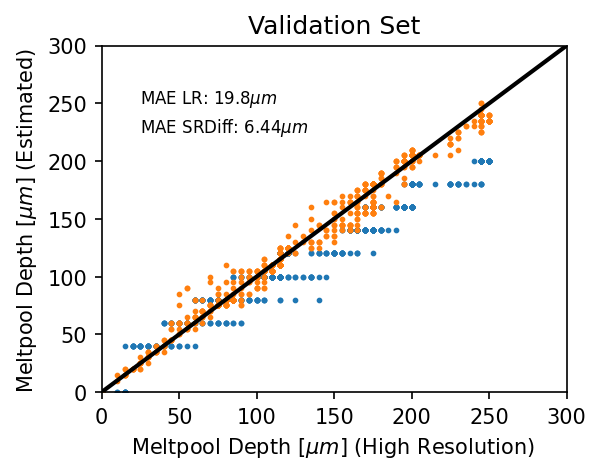

In [44]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(max_depth_gt, max_depth_diff, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth_diff)

plt.xlim(0,300)
plt.ylim(0,300)
# frame_tick()
plt.xlabel(r'Meltpool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Meltpool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.savefig(os.path.join(analysis_folder, 'melt_pool_depth_validation_gridsearch.png'))
plt.show()

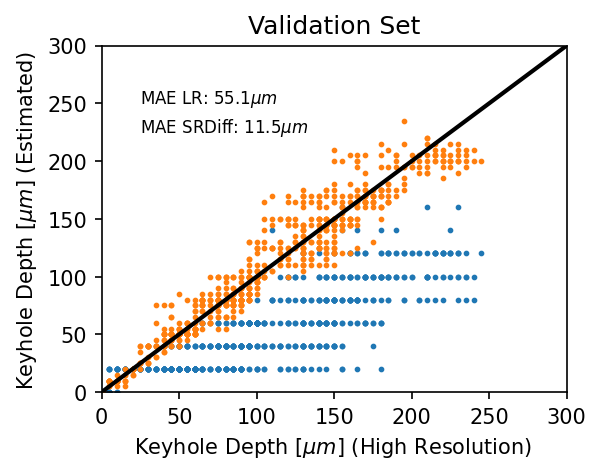

In [45]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth_diff)

plt.xlim(0,300)
plt.ylim(0,300)
# frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.savefig(os.path.join(analysis_folder, 'melt_pool_depth_validation_gridsearch.png'))
plt.show()